In [2]:
import pandas as pd

path = "dataMissingValue.csv"
df = pd.read_csv(path)

df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


In [3]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

In [4]:
percent_missing = 100 * df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

In [5]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [6]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [7]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [8]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [9]:
df_drop = df.drop(columns='Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [10]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [12]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


In [13]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = (df_filled2['Shoe Chart'].replace("", None).bfill())
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [14]:
df_filled2['Fav Fruit'] = (df_filled2['Fav Fruit'].replace("", None).ffill())
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


In [15]:
path = "weight-height_outlier.csv" 
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: ylabel='Height'>

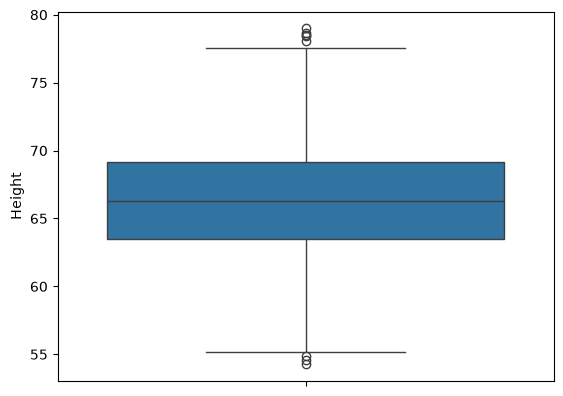

In [22]:
import seaborn as sns
sns.boxplot(df2['Height'])

<Axes: ylabel='Height'>

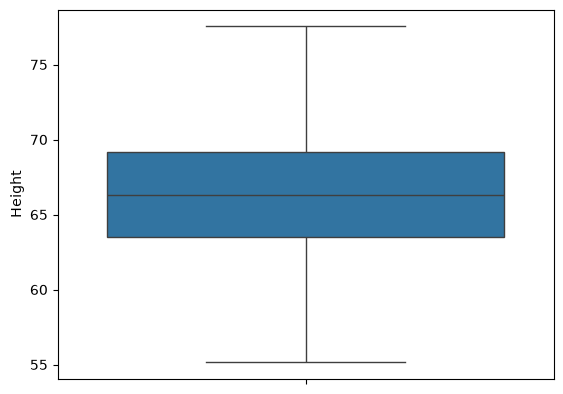

In [23]:
import numpy as np

# Identifikasi Q1 dan Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])

# Hitung IQR
iqr = q3 - q1

# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Hapus outliers
clean_data = df2[
    (df2['Height'] >= lower_bound) &
    (df2['Height'] <= upper_bound)
]

sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

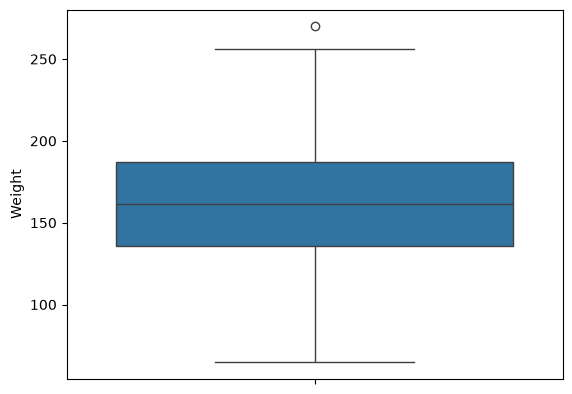

In [24]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

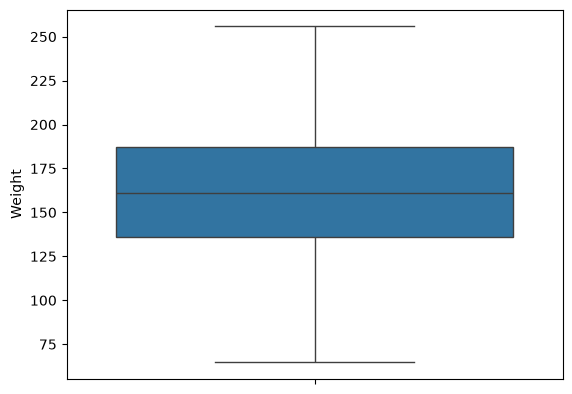

In [25]:
# Identifikasi Q1 dan Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])

# Hitung IQR
iqr = q3 - q1

# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Hapus outliers
clean_data = df2[
    (df2['Weight'] >= lower_bound) &
    (df2['Weight'] <= upper_bound)
]

sns.boxplot(clean_data['Weight'])

C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_10680\3000682688.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_10680\3000682688.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


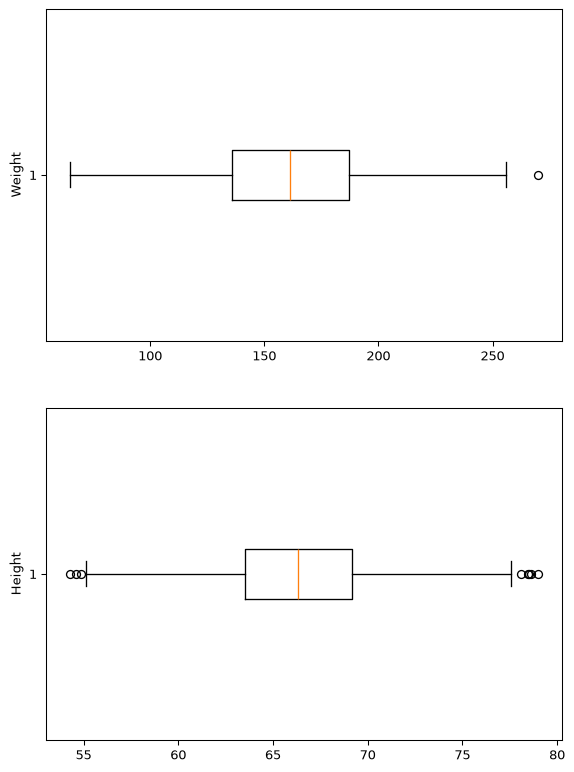

In [31]:
import matplotlib.pyplot as plt

# Membuat daftar kolom yang ingin dianalisis
columns_to_plot = ['Weight', 'Height']

# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(len(columns_to_plot),1,dpi=95,figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_10680\2629178014.py:36: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_10680\2629178014.py:36: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


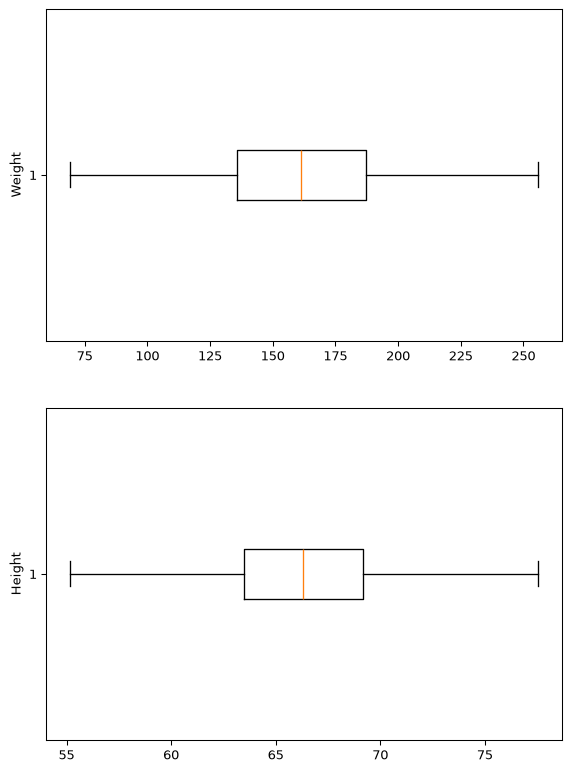

In [29]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()

    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]

    return df_cleaned


# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])


# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']

fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_10680\3781773255.py:36: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_10680\3781773255.py:36: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


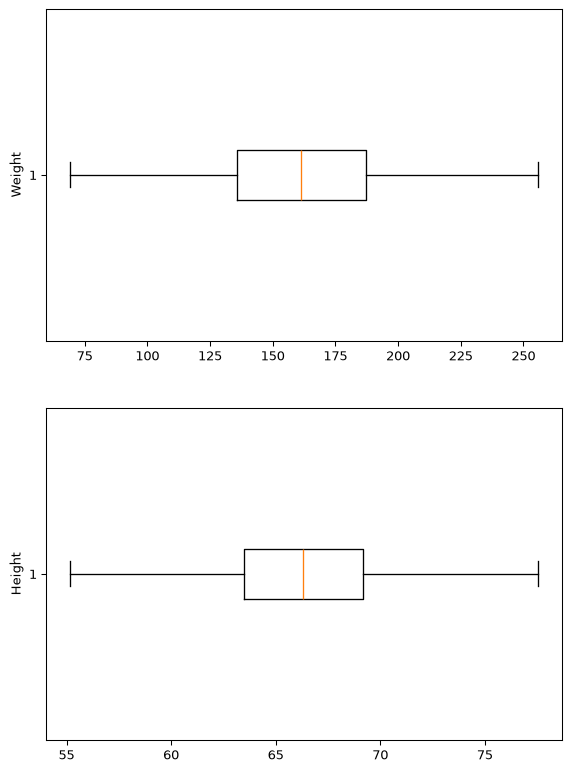

In [32]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) & 
            (df_cleaned[col] <= upper_bound)
        ]
    
    return df_cleaned

# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])


# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']

fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(
    include=[np.number]
).columns

non_numeric_cols = clean_data.select_dtypes(
    exclude=[np.number]
).columns

# Melakukan scaling pada kolom numerik
rescaled_numeric = scaler.fit_transform(
    clean_data[numeric_cols]
)

rescaled_numeric[:]

# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(
    rescaled_numeric,
    columns=numeric_cols,
    index=clean_data.index
)

# Gabungkan kembali dengan kolom non-numerik
# tanpa mengubah jumlah baris
final_df = pd.concat(
    [clean_data[non_numeric_cols], rescaled_df],
    axis=1
)

final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


In [10]:
#Tugas
import pandas as pd
import numpy as np

# Membaca dataset Titanic
path = "Titanic-Dataset.csv"
df = pd.read_csv(path)

# Menampilkan data
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
# Mengecek jumlah missing value pada setiap kolom
print("Jumlah missing value sebelum handling:")

df.isnull().sum()

Jumlah missing value sebelum handling:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# Menghitung persentase missing value
percent_missing = 100 * df.isnull().mean()

print("Persentase missing value:")
print(percent_missing)

Persentase missing value:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [13]:
# Mengidentifikasi kolom numerik
numeric_cols = df.select_dtypes(
    include=[np.number]
).columns

# Mengisi missing value pada kolom numerik dengan median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


# Mengidentifikasi kolom non-numerik
categorical_cols = df.select_dtypes(
    exclude=[np.number]
).columns

# Mengisi missing value pada kolom kategori dengan modus
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
# Mengidentifikasi kolom numerik
numeric_cols = df.select_dtypes(
    include=[np.number]
).columns

# Mengisi missing value pada kolom numerik dengan median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


# Mengidentifikasi kolom non-numerik
categorical_cols = df.select_dtypes(
    exclude=[np.number]
).columns

# Mengisi missing value pada kolom kategori dengan modus
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
# Mengecek kembali missing value
print("Jumlah missing value setelah handling:")

df.isnull().sum()

Jumlah missing value setelah handling:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [17]:
print(
    "Total seluruh missing value:",
    df.isnull().sum().sum()
)

Total seluruh missing value: 0


In [18]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,B96 B98,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,B96 B98,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset diabetes
path = "diabetes.csv"
df_diabetes = pd.read_csv(path)

# Menampilkan dataset
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [21]:
columns_to_check = [
    'Glucose',
    'BloodPressure',
    'BMI'
]

df_diabetes[columns_to_check].describe()

,Glucose,BloodPressure,BMI
count,768.000000,768.000000,768.000000
mean,120.894531,69.105469,31.992578
std,31.972618,19.355807,7.884160
min,0.000000,0.000000,0.000000
25%,99.000000,62.000000,27.300000
50%,117.000000,72.000000,32.000000
75%,140.250000,80.000000,36.600000
max,199.000000,122.000000,67.100000


C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_13060\2192133550.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_13060\2192133550.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_13060\2192133550.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(


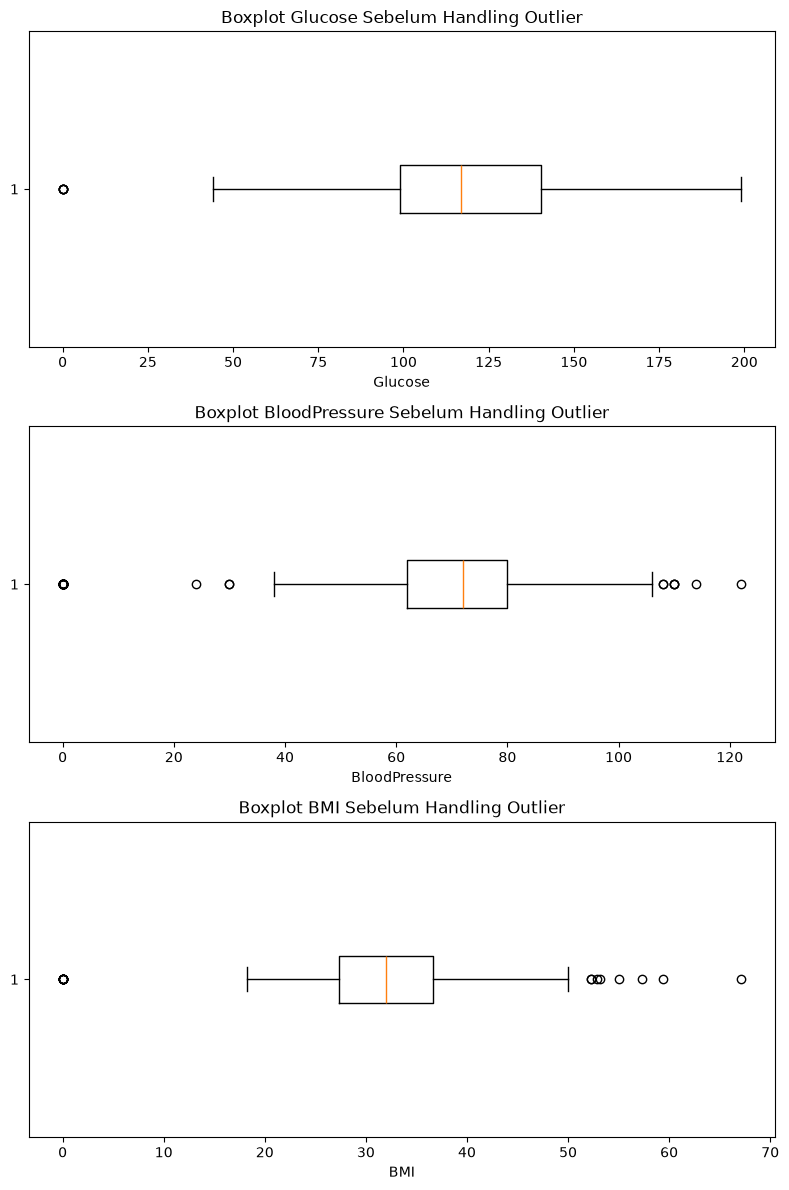

In [22]:
fig, axs = plt.subplots(
    3,
    1,
    figsize=(8, 12)
)

for i, col in enumerate(columns_to_check):
    axs[i].boxplot(
        df_diabetes[col],
        vert=False
    )

    axs[i].set_title(
        f'Boxplot {col} Sebelum Handling Outlier'
    )

    axs[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [23]:
for col in columns_to_check:

    # Q1 dan Q3
    q1 = df_diabetes[col].quantile(0.25)
    q3 = df_diabetes[col].quantile(0.75)

    # Menghitung IQR
    iqr = q3 - q1

    # Menentukan batas bawah dan batas atas
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Menentukan data outlier
    outliers = df_diabetes[
        (df_diabetes[col] < lower_bound) |
        (df_diabetes[col] > upper_bound)
    ]

    print("=" * 50)
    print("Kolom:", col)
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Jumlah Outlier:", len(outliers))

Kolom: Glucose
Q1: 99.0
Q3: 140.25
IQR: 41.25
Lower Bound: 37.125
Upper Bound: 202.125
Jumlah Outlier: 5
Kolom: BloodPressure
Q1: 62.0
Q3: 80.0
IQR: 18.0
Lower Bound: 35.0
Upper Bound: 107.0
Jumlah Outlier: 45
Kolom: BMI
Q1: 27.3
Q3: 36.6
IQR: 9.3
Lower Bound: 13.35
Upper Bound: 50.550000000000004
Jumlah Outlier: 19


In [24]:
clean_diabetes = df_diabetes.copy()

for col in columns_to_check:

    # Menghitung Q1 dan Q3
    q1 = clean_diabetes[col].quantile(0.25)
    q3 = clean_diabetes[col].quantile(0.75)

    # Menghitung IQR
    iqr = q3 - q1

    # Menentukan batas
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Menghapus data di luar batas
    clean_diabetes = clean_diabetes[
        (clean_diabetes[col] >= lower_bound) &
        (clean_diabetes[col] <= upper_bound)
    ]

In [25]:
print("Jumlah data sebelum handling outlier :", len(df_diabetes))
print("Jumlah data sesudah handling outlier :", len(clean_diabetes))
print("Jumlah data yang dihapus             :", 
      len(df_diabetes) - len(clean_diabetes))

Jumlah data sebelum handling outlier : 768
Jumlah data sesudah handling outlier : 709
Jumlah data yang dihapus             : 59


C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_13060\96212328.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_13060\96212328.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_13060\96212328.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(


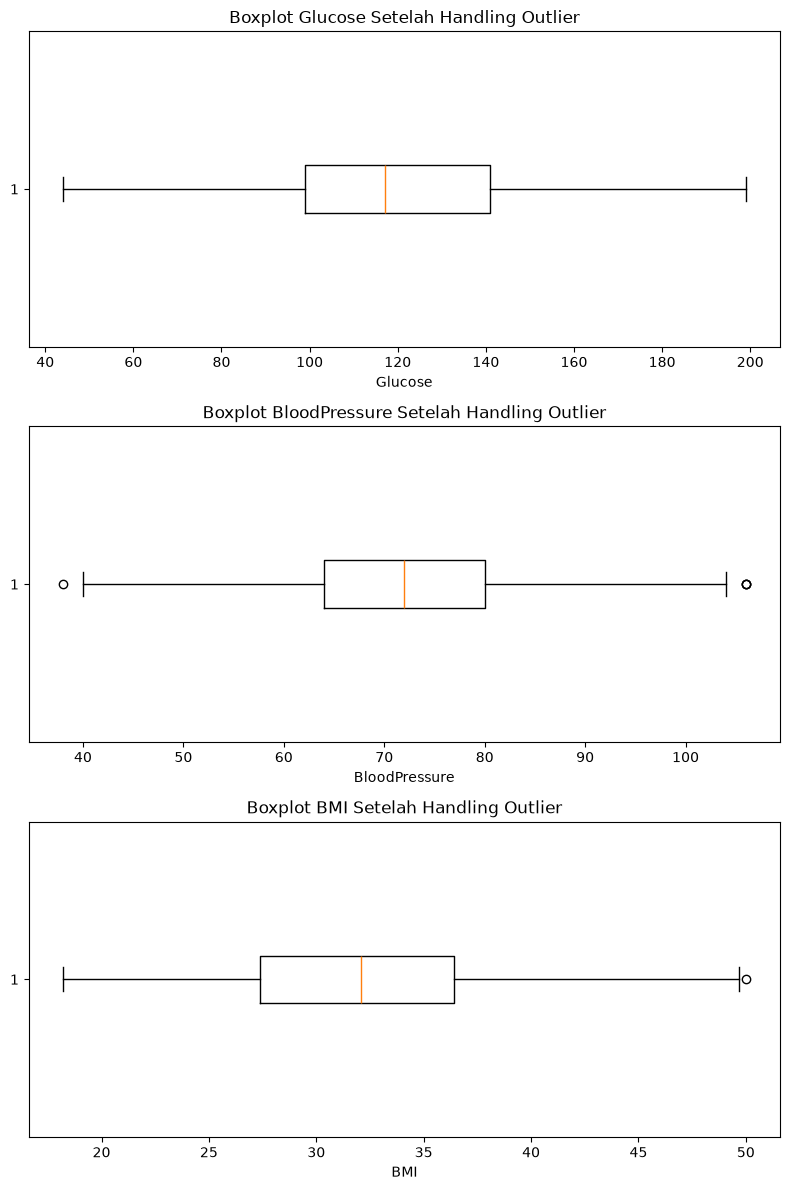

In [26]:
fig, axs = plt.subplots(
    3,
    1,
    figsize=(8, 12)
)

for i, col in enumerate(columns_to_check):

    axs[i].boxplot(
        clean_diabetes[col],
        vert=False
    )

    axs[i].set_title(
        f'Boxplot {col} Setelah Handling Outlier'
    )

    axs[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [27]:
clean_diabetes[columns_to_check].describe()

,Glucose,BloodPressure,BMI
count,709.000000,709.000000,709.000000
mean,121.629055,72.087447,32.173907
std,30.637977,11.403153,6.414215
min,44.000000,38.000000,18.200000
25%,99.000000,64.000000,27.400000
50%,117.000000,72.000000,32.100000
75%,141.000000,80.000000,36.400000
max,199.000000,106.000000,50.000000


In [28]:
clean_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
